# Alimentación del brazo: consumo eléctrico y fuente

**Taller de Proyecto I (E0306) — 2.º cuatrimestre 2026 — Grupo N.º 4**

---

## Alcance

Este cuaderno cierra la parte eléctrica: **de dónde sale la energía y cuánta hace
falta**. Responde cuatro preguntas:

1. A qué tensión se alimentan los servos.
2. Cuánta corriente consume el brazo, en régimen y en el peor instante.
3. Qué fuente hace falta, y qué capacitor, cable y fusible la acompañan.
4. Qué tiene que hacer el firmware para que esos números se cumplan.

Se apoya en el **cuaderno de dimensionamiento mecánico**, de donde sale el par
que entrega cada servo. Ese dato es el que permite calcular la corriente real en
lugar de suponer el peor caso absoluto.

> **Importante.** Todos los pares de este cuaderno son los que entrega el
> **servo**, no los que recibe la articulación. Entre uno y otro está la
> transmisión por engranajes: reduce 3:1 en el hombro y 2:1 en el codo, y
> multiplica 1:2 en la muñeca.

## El servo adoptado

| Característica | Valor |
|---|---|
| Par de bloqueo | 9,4 kg·cm a 4,8 V — 11,0 kg·cm a 6,0 V |
| Tensión de operación | 4,8 a 7,2 V |
| Corriente en marcha sin carga | 500 mA a 4,8 V — 900 mA a 6,0 V |
| Corriente de bloqueo | 2,5 A a 6,0 V |
| Masa | 55 g |

Los valores son los de la hoja de datos del fabricante. **El MG996R es un
producto de TowerPro**, no de Futaba; circulan clones reetiquetados que suelen
entregar algo menos, así que la sección 9 los pone a la cabeza de lo que hay que
medir.

---

# 1. Qué hay que alimentar

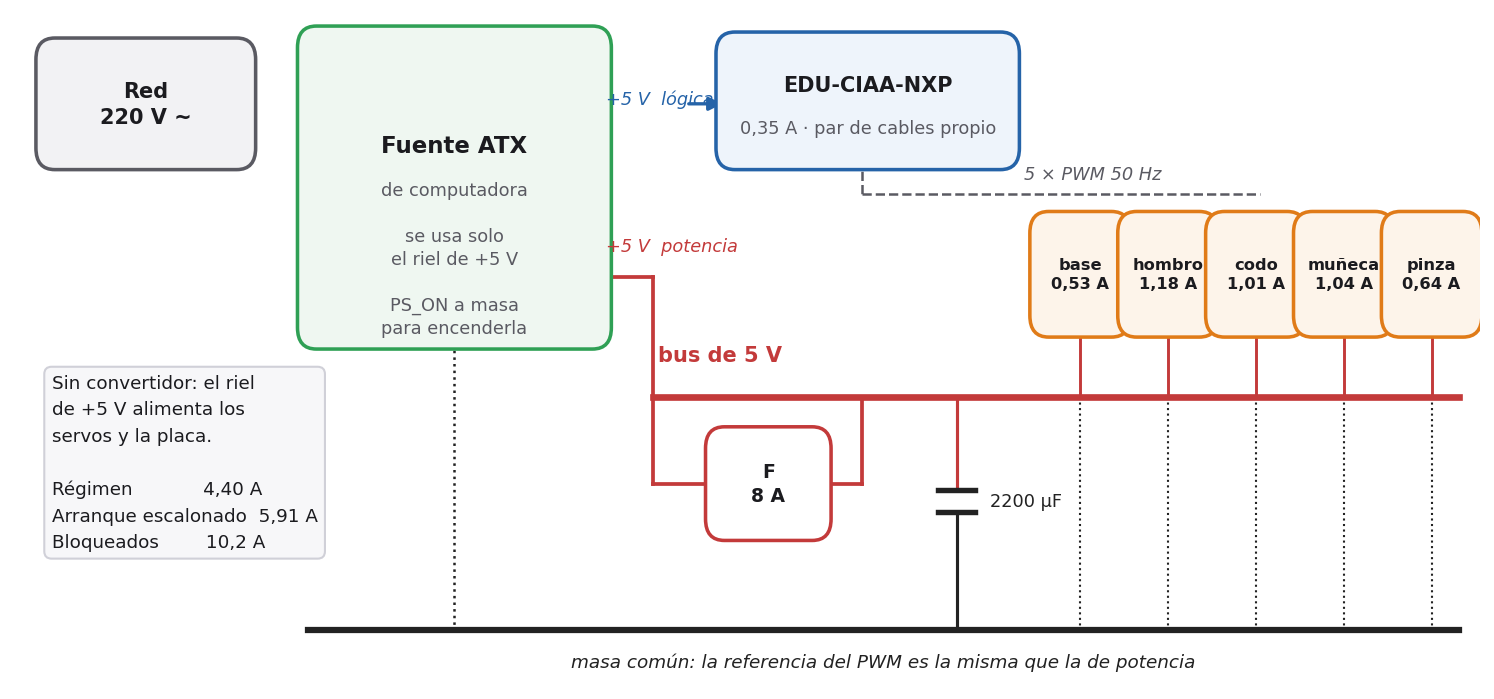

**Se usa una fuente de computadora en formato ATX, y solo su riel de +5 V.** No
hay convertidor: los servos y la placa se alimentan de la misma tensión.

| Rama | Consumo | Qué alimenta |
|---|---|---|
| Potencia | 4,40 A en régimen | los cinco servos |
| Lógica | ~0,35 A | la EDU-CIAA-NXP, los joysticks y margen para agregados |

El detalle de la rama de lógica:

| Elemento | Corriente | Origen del dato |
|---|---|---|
| EDU-CIAA-NXP | ~150 mA | consumo típico con el micro, el puente USB y los LED |
| Dos joysticks | < 1 mA | cuatro potenciómetros de 10 kΩ a 3,3 V |
| Margen para agregados | 200 mA | finales de carrera, un relé o señalización que se sumen |
| **Total** | **~0,35 A** | |

**Los servos se llevan el 93 % del consumo**, así que todo el resto del
documento es, en la práctica, sobre ellos.

Las dos ramas salen del mismo riel pero **con pares de cables distintos desde el
conector de la fuente**, unidos solo ahí. Una fuente ATX trae varios cables rojos
de +5 V justamente para eso. Si los servos y la placa compartieran el mismo par,
los picos de corriente de los servos se verían como caídas de tensión en la
alimentación de la placa.

---

# 2. Por qué alcanza con 5 V

La hoja de datos da el par de bloqueo en dos tensiones, y entre ellas crece de
forma aproximadamente lineal con la tensión, que es lo que se espera de un motor
de corriente continua. Eso hay que cruzarlo con lo que cada servo tiene que
entregar.

Y acá entra el resultado que hace posible todo este cuaderno: **la transmisión
por engranajes bajó tanto el par que los servos deben entregar que el riel de
5 V alcanza**. Sin transmisión no alcanzaría ni con 6 V.

In [1]:
import math

FS = 2.0                    # el mismo factor de seguridad del cuaderno mecanico
TAU_48, TAU_60 = 9.4, 11.0  # kg.cm, hoja de datos del MG996R

def par_disponible(V):
    '''Par de bloqueo del MG996R, interpolado linealmente con la tension.'''
    return TAU_48 + (TAU_60 - TAU_48) * (V - 4.8) / (6.0 - 4.8)

# par que debe entregar el servo del hombro, segun como se lo acople
CASOS = [("sin transmision",   12.27, "—"),
         ("reduccion 2,5:1",    4.91, "20:50"),
         ("reduccion 3:1",      4.09, "20:60")]

print(f"{'acople':<20}{'dientes':>9}{'par servo':>11}{'x FS 2':>9}"
      f"{'disp. 5 V':>11}{'disp. 6 V':>11}")
print('-' * 72)
for nombre, tau, dientes in CASOS:
    d5, d6 = par_disponible(4.89), par_disponible(6.0)
    print(f"{nombre:<20}{dientes:>9}{tau:>11.2f}{tau*FS:>9.2f}"
          f"{d5:>8.2f} {'OK ' if d5 >= tau*FS else 'NO '}"
          f"{d6:>8.2f} {'OK' if d6 >= tau*FS else 'NO'}")

V_SERVO = 4.89              # V que llegan al servo (5 V de la ATX - caida del cable)
TAU_SERVO = par_disponible(V_SERVO)
print(f"\nSe adopta el riel de +5 V. Descontando la caida del cable (seccion 5),"
      f"\nal servo llegan {V_SERVO} V y el par disponible es {TAU_SERVO:.2f} kg.cm.")

acople                dientes  par servo   x FS 2  disp. 5 V  disp. 6 V
------------------------------------------------------------------------
sin transmision             —      12.27    24.54    9.52 NO    11.00 NO
reduccion 2,5:1         20:50       4.91     9.82    9.52 NO    11.00 OK
reduccion 3:1           20:60       4.09     8.18    9.52 OK    11.00 OK

Se adopta el riel de +5 V. Descontando la caida del cable (seccion 5),
al servo llegan 4.89 V y el par disponible es 9.52 kg.cm.


**Con 3:1 en el hombro, el riel de 5 V alcanza con 16 % de margen** sobre el
factor de seguridad. Con 2,5:1 no alcanzaría y habría que agregar un convertidor
de 12 V a 6 V.

Esa es la decisión: **se gasta un engranaje más grande en vez de un componente
electrónico**. El engranaje cuesta dos horas de impresora; el convertidor cuesta
dinero, pide disipador, disipa 5 W y agrega un modo de falla nuevo —si su preset
se mueve, la salida puede subir a 12 V y quemar los cinco servos de una vez.

El precio es recorrido: el hombro pasa de 72° a 60° de barrido. El cuaderno
mecánico verifica que alcanza.

> **Si el ensayo mostrara que 60° no son suficientes**, el camino de vuelta es
> alimentar a 6 V desde el riel de +12 V con un convertidor reductor, y volver a
> la relación 2,5:1. El resto del diseño —bus, capacitor, cable, fusible— no
> cambia.

---

# 3. Cuánta corriente pide un servo

Adentro de un servo hay un motor de corriente continua, y en un motor de continua
el par es proporcional a la corriente:

$$\tau = k_t \cdot I$$

El servo además consume algo aunque no haga fuerza: la fricción del tren de
engranajes y la electrónica de control. Esa es la corriente **en marcha sin
carga**. El otro extremo, con el eje bloqueado, es la **corriente de bloqueo**.
Entre esos dos puntos la relación es una recta:

$$I(\tau) = I_{vacío} + \left(I_{bloqueo} - I_{vacío}\right)\cdot\frac{\tau}{\tau_{disponible}}$$

Lo importante es lo que esto evita: **no hace falta suponer que los servos están
bloqueados**. Del cuaderno mecánico sabemos qué par entrega cada uno.

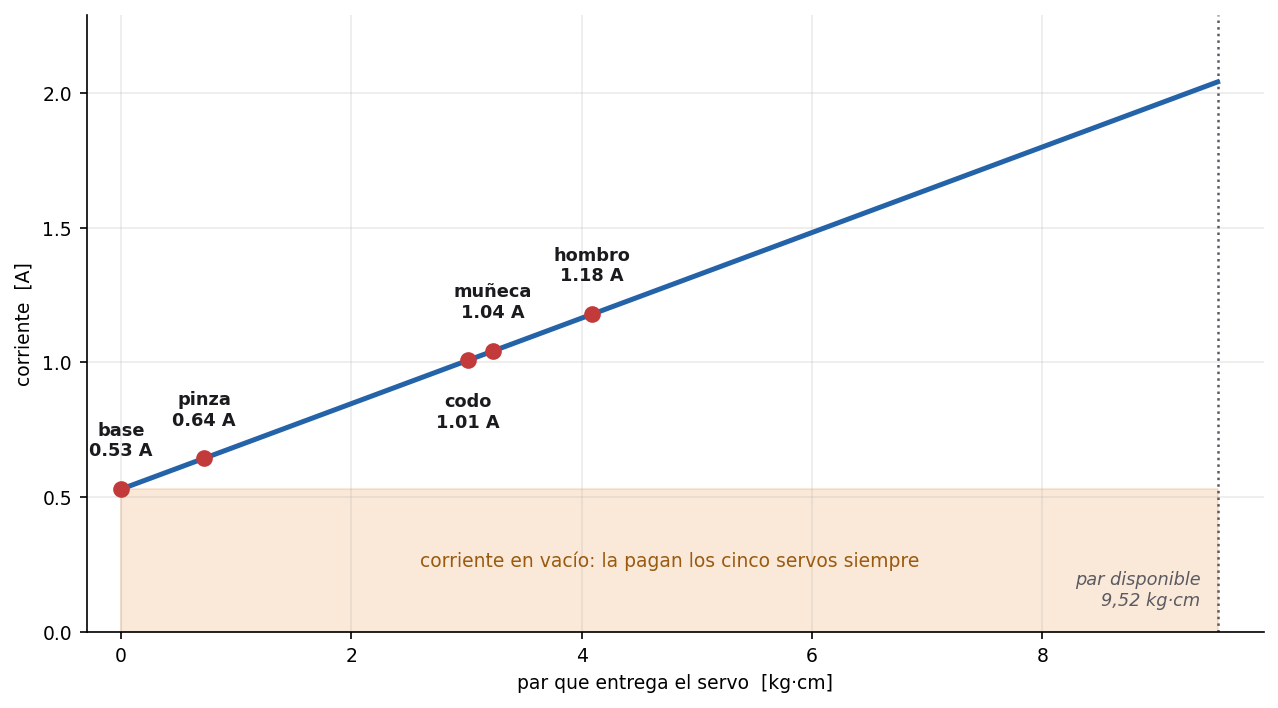

In [2]:
# Hoja de datos a 6 V, escalada a la tension de trabajo.
# La corriente de bloqueo es V/R con R fija, asi que escala con la tension.
I_VACIO_48, I_VACIO_60 = 0.50, 0.90     # A, en marcha sin carga
I_BLOQUEO_60 = 2.50                     # A, con el eje bloqueado, a 6 V

I_VACIO   = I_VACIO_48 + (I_VACIO_60 - I_VACIO_48) * (V_SERVO - 4.8) / 1.2
I_BLOQUEO_1 = I_BLOQUEO_60 * V_SERVO / 6.0

# articulacion y par QUE ENTREGA EL SERVO [kg.cm] (cuaderno de dimensionamiento)
SERVOS = [("base",    0.00),    # eje vertical: no tiene par gravitatorio
          ("hombro",  4.09),    # 12,27 en la junta, reduccion 20:60
          ("codo",    3.01),    # 6,02 en la junta, reduccion 20:40
          ("muneca",  3.23),    # 1,62 en la junta, multiplicacion 40:20
          ("pinza",   0.72)]    # por fuerza de agarre, transmision directa

def corriente(tau):
    return I_VACIO + (I_BLOQUEO_1 - I_VACIO) * (tau / TAU_SERVO)

print(f"a {V_SERVO} V:  I_vacio = {I_VACIO:.2f} A    "
      f"I_bloqueo = {I_BLOQUEO_1:.2f} A\n")
print(f"{'servo':<9}{'par servo':>12}{'% del disp.':>13}{'I regimen':>12}")
print('-' * 46)
I_REGIMEN = 0.0
for nombre, tau in SERVOS:
    i = corriente(tau)
    I_REGIMEN += i
    print(f"{nombre:<9}{tau:>9.2f} kg{tau/TAU_SERVO*100:>11.0f} %{i:>9.2f} A")
I_BLOQUEO = len(SERVOS) * I_BLOQUEO_1
print('-' * 46)
print(f"{'SUMA':<9}{'':>12}{'':>13}{I_REGIMEN:>9.2f} A")
print(f"\nlos cinco bloqueados a la vez: {I_BLOQUEO:.1f} A")
print(f"potencia en regimen: {5.0*I_REGIMEN:.1f} W")

a 4.89 V:  I_vacio = 0.53 A    I_bloqueo = 2.04 A

servo       par servo  % del disp.   I regimen
----------------------------------------------
base          0.00 kg          0 %     0.53 A
hombro        4.09 kg         43 %     1.18 A
codo          3.01 kg         32 %     1.01 A
muneca        3.23 kg         34 %     1.04 A
pinza         0.72 kg          8 %     0.64 A
----------------------------------------------
SUMA                                   4.40 A

los cinco bloqueados a la vez: 10.2 A
potencia en regimen: 22.0 W


Dos observaciones:

- **La corriente en vacío domina.** Aun sin hacer fuerza, los cinco servos en
  movimiento consumen 2,6 A, que son el 60 % del total. La transmisión bajó el
  par pero no toca este término, así que el ahorro de corriente es menor de lo
  que uno esperaría.
- **La muñeca es la única que consume más por culpa de la transmisión**: ahí los
  engranajes multiplican el recorrido en vez del par, así que el servo entrega el
  doble de lo que recibe la articulación. Es el precio de los 360° que necesita.

Los 10,2 A de los cinco bloqueados no corresponden a ninguna situación de
trabajo, pero aparecen por un instante en el arranque.

---

# 4. El arranque escalonado

Cuando un servo arranca desde el reposo consume, durante unos 150 ms, una
corriente cercana a la de bloqueo: tiene que acelerar el brazo antes de llegar a
su velocidad de régimen. Si los cinco arrancan en el mismo instante, esos picos
se suman.

**Con una fuente de PC el pico no es un problema de capacidad**: el riel de +5 V
de cualquier ATX entrega 20 A o más, así que los 10,2 A del arranque simultáneo
los da sin despeinarse. El problema es otro, y es más sutil: **la caída en el
cable**. Esa corriente atraviesa el cableado, y cuanto más alta, menos tensión
llega al servo. Como el par crece con la tensión, el brazo pierde fuerza
justo en el instante en que más la necesita.

In [3]:
R_CABLE = 0.0233            # ohm, cable de 1,5 mm2 ida y vuelta (seccion 5)

I_PICO_JUNTOS = I_BLOQUEO
# Escalonando, en cada instante hay UN servo arrancando y el resto en regimen
I_PICO_ESCALONADO = I_REGIMEN + (I_BLOQUEO_1 - I_VACIO)

print(f"{'condicion':<24}{'corriente':>11}{'caida':>9}{'V en el servo':>15}"
      f"{'par disp.':>11}")
print('-' * 71)
for etiqueta, I in (("regimen", I_REGIMEN),
                    ("arranque escalonado", I_PICO_ESCALONADO),
                    ("los cinco juntos", I_PICO_JUNTOS)):
    caida = R_CABLE * I
    v = 5.0 - caida
    print(f"{etiqueta:<24}{I:>9.2f} A{caida:>8.2f} V{v:>13.2f} V"
          f"{par_disponible(v):>9.2f} kg")

print(f"\nel escalonado baja el pico un "
      f"{100*(1 - I_PICO_ESCALONADO/I_PICO_JUNTOS):.0f} %")
print(f"par que necesita el hombro con FS 2: {4.09*FS:.2f} kg.cm")

condicion                 corriente    caida  V en el servo  par disp.
-----------------------------------------------------------------------
regimen                      4.40 A    0.10 V         4.90 V     9.53 kg
arranque escalonado          5.91 A    0.14 V         4.86 V     9.48 kg
los cinco juntos            10.19 A    0.24 V         4.76 V     9.35 kg

el escalonado baja el pico un 42 %
par que necesita el hombro con FS 2: 8.18 kg.cm


**El resultado es tranquilizador: ni en el peor caso el pico llega a comprometer
el brazo.** Con los cinco servos arrancando juntos la caída es de 0,24 V y el par
disponible baja a 9,35 kg·cm, todavía por encima de los 8,18 que el hombro
necesita con el factor de seguridad.

Conviene decirlo explícitamente, porque **con una fuente dedicada no sería así**.
La holgura viene de la fuente de PC: tiene corriente de sobra y su tensión no se
hunde con el pico.

Aun así **el firmware escalona el arranque 150 ms entre ejes**, por dos razones
que no cuestan nada: baja el pico un 42 %, lo que reduce el esfuerzo sobre el
fusible y los conectores; y deja margen por si el servo real resulta más flojo
que la hoja de datos. Contra los 2 segundos que dura el tramo más corto de la
trayectoria, el retardo es imperceptible para el operador.

Queda como **requerimiento de software**, junto con los tiempos mínimos de la
trayectoria: *el firmware arranca los ejes escalonados 150 ms*.

---

# 5. Los cables

Un cable fino no impide que el brazo funcione: hace que al servo le llegue menos
tensión que la de la fuente, y como el par crece con la tensión, **un cable fino
le quita par al brazo**. Trabajando a 5 V, donde el hombro usa el 86 % de lo que
el criterio permite, eso importa más que de costumbre.

$$R = \rho\,\frac{L}{S}, \qquad \rho_{cobre} = 0{,}0175\ \frac{\Omega\cdot mm^2}{m}$$

donde $L$ es la longitud total del conductor (ida **y** vuelta) y $S$ la sección.
El criterio adoptado es que la caída no supere el **3 % de la tensión**, el valor
habitual en instalaciones de baja tensión.

In [4]:
RHO = 0.0175                # ohm.mm2/m, cobre
LARGO = 2.0                 # m, ida y vuelta desde la fuente hasta los servos
V_BUS = 5.0
CAIDA_MAX = 0.03 * V_BUS

print(f"Caida admitida: {CAIDA_MAX:.2f} V  (3 % de {V_BUS:.0f} V)")
print(f"Seccion minima: {RHO*LARGO*I_REGIMEN/CAIDA_MAX:.2f} mm2\n")
print(f"{'seccion':>9}{'R':>9}{'caida':>9}{'':>9}")
print('-' * 36)
for S in (0.50, 0.75, 1.00, 1.50, 2.50):
    R = RHO * LARGO / S
    caida = R * I_REGIMEN
    print(f"{S:>6.2f} mm2{R:>8.3f}{caida:>8.2f} V {caida/V_BUS*100:>5.1f} %"
          f"   {'OK' if caida <= CAIDA_MAX else 'excede'}")

Caida admitida: 0.15 V  (3 % de 5 V)
Seccion minima: 1.03 mm2

  seccion        R    caida         
------------------------------------
  0.50 mm2   0.070    0.31 V   6.2 %   excede
  0.75 mm2   0.047    0.21 V   4.1 %   excede
  1.00 mm2   0.035    0.15 V   3.1 %   excede
  1.50 mm2   0.023    0.10 V   2.1 %   OK
  2.50 mm2   0.014    0.06 V   1.2 %   OK


Se adopta **1,5 mm² (AWG 16)** para la rama de potencia: es el primer valor
comercial que cumple, y es el que usa la sección 4 para calcular la caída. Con el
cable de 0,5 mm² que traen los propios servos la caída sería del 6,2 %, el doble
del criterio.

Los cables de señal no llevan corriente apreciable, así que ahí la sección se
elige por resistencia mecánica.

Una regla de armado que vale más que la sección: **conectar los servos en
estrella desde el capacitor, no en cadena**. Colgados uno del otro, el último de
la fila ve la caída de todos los que lo preceden.

---

# 6. El capacitor del bus

El control interno del servo conmuta el motor a varios kHz. Esos transitorios
duran decenas de microsegundos y la fuente, que está a dos metros de cable, no
llega a responderlos: el bus se hunde momentáneamente. Un capacitor sobre el bus
los absorbe.

$$C = \frac{I \cdot \Delta t}{\Delta V}$$

In [5]:
I_CONM, DT, DV = 3.0, 100e-6, 0.20     # A, s, V admisible de hundimiento
C = I_CONM * DT / DV
print(f"{I_CONM:.0f} A durante {DT*1e6:.0f} us con una caida maxima de {DV} V")
print(f"C = I dt / dV = {C*1e6:,.0f} uF   -> se adopta 2200 uF (valor comercial)")

3 A durante 100 us con una caida maxima de 0.2 V
C = I dt / dV = 1,500 uF   -> se adopta 2200 uF (valor comercial)


Se monta sobre el bus de potencia, **lo más cerca posible de los servos**, no
junto a la fuente: su función es justamente cubrir lo que el cable no deja pasar
rápido.

> **Lo que el capacitor no hace.** No reemplaza al arranque escalonado. El pico
> de arranque dura 150 ms, mil quinientas veces más que un transitorio de
> conmutación; sostenerlo exigiría cientos de miles de microfaradios. Son dos
> herramientas para dos escalas de tiempo.

---

# 7. La fuente

| Ítem | Valor adoptado | De dónde sale |
|---|---|---|
| Fuente | **ATX de computadora, riel de +5 V** | sección 2 |
| Corriente en régimen | 4,40 A | sección 3 |
| Pico de arranque | 5,91 A | sección 4, con el escalonado del firmware |
| Capacitor de bus | 2200 µF | sección 6 |
| Cable de potencia | 1,5 mm² (AWG 16) | sección 5 |
| Fusible | 8 A retardado | sección 8 |
| Rama de lógica | 5 V / 0,35 A, del mismo riel con cables propios | sección 1 |

Cualquier ATX en desuso sirve: el riel de +5 V de las más modestas entrega 20 A,
cuatro veces lo que pide el brazo. No hay que elegir por potencia sino por que
funcione.

## Cómo se enciende una ATX

No arranca al enchufarla: espera la orden de la placa madre. Hay que hacer dos
cosas:

1. **Puentear PS_ON a masa.** Es el cable verde del conector de 24 pines; se une
   a cualquier cable negro. Conviene hacerlo a través de un interruptor, que pasa
   a ser el encendido del brazo.
2. **Poner una carga mínima** si la fuente no arranca sola. Las fuentes viejas
   necesitan consumo para regular; una resistencia de 10 Ω y 10 W en el riel de
   +5 V alcanza. Las modernas suelen arrancar sin esto, así que se prueba primero
   sin ella.

Un detalle a favor: la masa de la ATX ya está unida al chasis y a la tierra del
enchufe, así que la tierra común de la sección 8 queda resuelta por
construcción.

## El riesgo que agrega

**La capacidad de cortocircuito.** Una fuente dedicada de 5 A, ante un error de
cableado, entrega 5 A y se protege sola. Una ATX entrega **más de 20 A** y va a
alimentar el error hasta que algo se queme: el cable, un servo o una pista. Con
ATX, el fusible deja de ser una buena práctica y pasa a ser **obligatorio**, y
tiene que estar lo más cerca posible de la fuente.

---

# 8. Protecciones y reglas de cableado

Ninguna de estas sale de un cálculo, pero todas evitan un modo de falla concreto.

| Medida | Qué previene |
|---|---|
| **Fusible de 8 A retardado** junto a la fuente | Un cortocircuito en el cableado de los servos. Es retardado para que no corte con el pico de 5,9 A del arranque, y está por debajo de lo que tolera el cable de 1,5 mm². Con la fuente de PC no es opcional. |
| **Tierra común entre las dos ramas** | El PWM se mide contra GND. Si las masas no están unidas, los servos no responden o tiemblan. Es el error de cableado más frecuente en este montaje. Con la ATX queda resuelto por construcción. |
| **Pares de cables separados para potencia y lógica** | Los picos de los servos se verían como caídas en la alimentación de la placa, que puede resetearse. |
| **No alimentar los servos desde el USB de la EDU-CIAA** | El USB entrega 0,5 A y los servos piden hasta 5,9 A. La placa se resetea o se daña el puerto de la computadora. |
| **Conector polarizado en la entrada del bus** | Invertir la polaridad quema los cinco servos de una vez. |
| **Interruptor que abra solo la rama de potencia** | Permite frenar el brazo dejando la lógica viva, para que el firmware sepa que se cortó y no intente seguir moviéndose al volver la tensión. |

---

# 9. Qué hay que medir

Este cuaderno se apoya en **tres números de la hoja de datos** —el par de
bloqueo, la corriente en vacío y la de bloqueo— que los clones no siempre
respetan. Son el eslabón más débil.

1. **Par de bloqueo real, alimentado a 5 V.** Es la medición más importante: el
   hombro usa el 86 % de lo que el criterio permite. Con el servo sujeto y un
   brazo de palanca conocido, se cuelga peso hasta que cede. Si da menos de
   9,5 kg·cm hay que bajar la carga del recipiente, o pasar a 6 V con
   convertidor.
2. **Corriente en marcha sin carga.** Multímetro en serie con un solo servo,
   moviéndose sin carga. Es el término que domina el consumo total.
3. **Corriente de bloqueo.** El mismo montaje, trabando el eje con la mano un
   instante breve. Hay que ser rápido: bloqueado, un servo se calienta en
   segundos.
4. **Corriente con la carga real**, con el brazo de ensayo y la pesa en la punta.
   Es el valor a comparar contra la columna «I régimen» de la sección 3.
5. **Caída en el cable.** Medir la tensión en los bornes del servo más lejano,
   con el brazo en su pose de mayor esfuerzo, y verificar que no baje más del
   3 % respecto de la fuente. Es la que realimenta el par disponible de la
   sección 2.

Con esas cinco mediciones el cuaderno deja de apoyarse en hojas de datos y pasa a
apoyarse en datos propios. Si los valores difieren, solo hay que reemplazar las
constantes de la sección 3 y volver a ejecutar: todo lo demás se recalcula solo.